In [1]:
import json
import os

os.environ["SPS_HOME"] = "/Users/z5114326/Documents/GitHub/python-fsps/src/fsps/libfsps"

import fsps
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fsps.filters import FILTERS

In [2]:
filters = fsps.list_filters()

for f in filters:
    print(f)


v
u
b
buser_b
cousins_r
cousins_i
cfht_b
cfht_r
cfht_i
2mass_j
2mass_h
2mass_ks
sdss_u
sdss_g
sdss_r
sdss_i
sdss_z
wfpc2_f255w
wfpc2_f300w
wfpc2_f336w
wfpc2_f439w
wfpc2_f450w
wfpc2_f555w
wfpc2_f606w
wfpc2_f814w
wfpc2_f850lp
wfc_acs_f435w
wfc_acs_f475w
wfc_acs_f555w
wfc_acs_f606w
wfc_acs_f625w
wfc_acs_f775w
wfc_acs_f814w
wfc_acs_f850lp
wfc3_uvis_f218w
wfc3_uvis_f225w
wfc3_uvis_f275w
wfc3_uvis_f336w
wfc3_uvis_f390w
wfc3_uvis_f438w
wfc3_uvis_f475w
wfc3_uvis_f555w
wfc3_uvis_f606w
wfc3_uvis_f775w
wfc3_uvis_f814w
wfc3_uvis_f850lp
wfc3_ir_f098m
wfc3_ir_f105w
wfc3_ir_f110w
wfc3_ir_f125w
wfc3_ir_f140w
wfc3_ir_f160w
irac_1
irac_2
irac_3
irac_4
isaac_ks
fors_v
fors_r
nicmos_f110w
nicmos_f160w
galex_fuv
galex_nuv
des_g
des_r
des_i
des_z
des_y
wfcam_z
wfcam_y
wfcam_j
wfcam_h
wfcam_k
steidel_un
steidel_g
steidel_rs
steidel_i
megacam_u
megacam_g
megacam_r
megacam_i
megacam_z
wise_w1
wise_w2
wise_w3
wise_w4
uvot_w2
uvot_m2
uvot_w1
mips_24
mips_70
mips_160
scuba_450wb
scuba_850wb
pacs_70
pacs_100
pacs_

In [3]:
# ---------------------------
# Settings
# ---------------------------
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
band_type = "SDSS"
bands = ["sdss_g", "sdss_z"]

it_id = "it001"
snap = 600

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"


# ---------------------------
# FSPS configuration (ONCE)
# ---------------------------
compute_vega_mags = band_type == "JC"

sp = fsps.StellarPopulation(
    imf_type=2,
    zcontinuous=1,
    compute_vega_mags=compute_vega_mags,
)


sp.params["add_dust_emission"] = False
sp.params["add_neb_continuum"] = False
sp.params["add_neb_emission"] = False
sp.params["add_agb_dust_model"] = False
sp.params["dust1"] = 0.0
sp.params["dust2"] = 0.0
sp.params["fcstar"] = 0.0
sp.params["agb_dust"] = 0.0
sp.params["tpagb_norm_type"] = 0


# ---------------------------
# Load data
# ---------------------------
with h5py.File(ghost_file, "r") as ghost_data:
    snp_id = gc_utils.snapshot_name(snap)
    snp_dat = ghost_data[it_id]["snapshots"][snp_id]
    src_dat = ghost_data[it_id]["source"]

    gcids = snp_dat["gcid"][()]
    ages = snp_dat["age"][()]  # Gyr
    mass = 10 ** snp_dat["logm"][()]  # Msun

    # fast metallicity lookup
    feh_map = dict(zip(src_dat["gcid"], src_dat["feh"]))
    fehs = np.array([feh_map[g] for g in gcids])


# ---------------------------
# BUILD UNIQUE SSP GRID
# ---------------------------
# Stack parameters -> find unique SSPs
ssp_params = np.column_stack((ages, fehs))
unique_ssps, inv_idx = np.unique(ssp_params, axis=0, return_inverse=True)

n_ssp = len(unique_ssps)
print(f"Computing {n_ssp} unique SSPs (instead of {len(ages)})")


# ---------------------------
# Run FSPS ONCE per SSP
# ---------------------------
nband = len(bands)
ssp_mag = np.empty((n_ssp, nband))
ssp_mass = np.empty(n_ssp)

for i, (age, feh) in enumerate(unique_ssps):
    if i % 100 == 0 or i == n_ssp - 1:
        print(f"SSP {i + 1}/{n_ssp}")

    sp.params["logzsol"] = feh
    ssp_mag[i, :] = sp.get_mags(tage=age, bands=bands)
    ssp_mass[i] = sp.stellar_mass


# Mass scaling (vectorized, multi-band)
scaling = mass / ssp_mass[inv_idx]  # (Nstar,)
mags = ssp_mag[inv_idx, :] - 2.5 * np.log10(scaling)[:, None]


Computing 89 unique SSPs (instead of 227)
SSP 1/89
SSP 89/89


Text(0.5, 0, 'g - z')

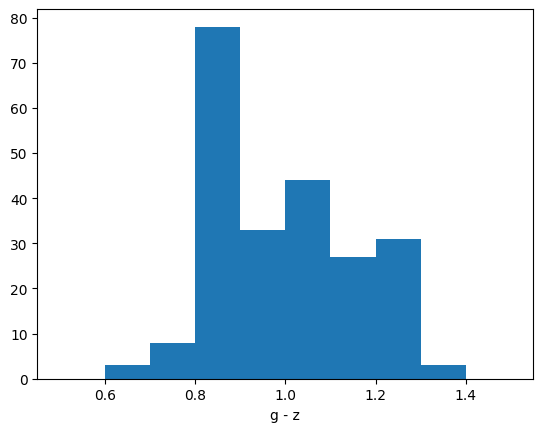

In [4]:
cols = mags[:, 0] - mags[:, 1]
bins = np.arange(0.5, 1.6, 0.1)
plt.hist(cols, bins=bins)
plt.xlabel("g - z")